In [1]:
import math
import time
import matplotlib.pyplot as plt

In [2]:
ciudades = [

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)
]

cantidad_ciudades = len(ciudades)

print("Cantidad de ciudades:", cantidad_ciudades)

Cantidad de ciudades: 16


In [3]:
def distancia(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0])**2 +
        (p1[1] - p2[1])**2
    )

matriz = []

for i in range(cantidad_ciudades):

    fila = []

    for j in range(cantidad_ciudades):

        if i == j:
            fila.append(0)

        else:
            fila.append(
                distancia(
                    ciudades[i],
                    ciudades[j]
                )
            )

    matriz.append(fila)

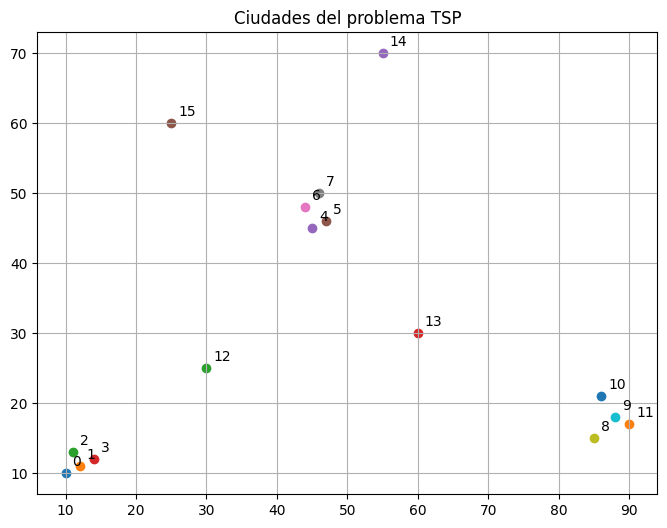

In [4]:
plt.figure(figsize=(8,6))

for indice, (x,y) in enumerate(ciudades):

    plt.scatter(x, y)

    plt.text(
        x + 1,
        y + 1,
        str(indice)
    )

plt.title("Ciudades del problema TSP")
plt.grid(True)

plt.show()

In [5]:
class EstadisticasPrice:

    def __init__(self):

        self.nodos_explorados = 0
        self.nodos_podados = 0
        self.columnas_generadas = 0

In [9]:
def calcular_cota(
        ruta_actual,
        costo_actual,
        visitados,
        matriz):

    n = len(matriz)

    estimacion = costo_actual

    for ciudad in range(n):

        if ciudad not in visitados:

            menor = float('inf')

            for destino in range(n):

                if ciudad != destino:

                    if matriz[ciudad][destino] < menor:

                        menor = matriz[ciudad][destino]

            estimacion += menor

    return estimacion

In [6]:
def generar_columnas(
        ciudad_actual,
        visitados,
        matriz,
        max_columnas=3):

    candidatos = []

    for ciudad in range(len(matriz)):

        if ciudad not in visitados:

            candidatos.append(
                (
                    ciudad,
                    matriz[ciudad_actual][ciudad]
                )
            )

    candidatos.sort(
        key=lambda x: x[1]
    )

    resultado = []

    limite = min(
        max_columnas,
        len(candidatos)
    )

    for i in range(limite):

        resultado.append(
            candidatos[i][0]
        )

    return resultado

#Generación de columnas (Price): En cada nivel del árbol de búsqueda no se exploran todas las ciudades disponibles. Primero se ordenan las ciudades no visitadas según su distancia a la ciudad actual y luego se seleccionan únicamente las más cercanas. Estas ciudades seleccionadas se consideran las "columnas generadas" y son las únicas que continúan la exploración. El objetivo es reducir el tamaño del espacio de búsqueda y acelerar la obtención de una solución

In [7]:
def branch_and_price(matriz):

    n = len(matriz)

    mejor_costo = float('inf')
    mejor_ruta = None

    stats = EstadisticasPrice()

    def explorar(
            ciudad_actual,
            visitados,
            ruta,
            costo_actual):

        nonlocal mejor_costo
        nonlocal mejor_ruta

        stats.nodos_explorados += 1

        if len(visitados) == n:

            costo_total = (
                costo_actual
                + matriz[ciudad_actual][0]
            )

            if costo_total < mejor_costo:

                mejor_costo = costo_total
                mejor_ruta = ruta[:] + [0]

            return

        limite = calcular_cota(
            ruta,
            costo_actual,
            visitados,
            matriz
        )

        if limite >= mejor_costo:

            stats.nodos_podados += 1
            return

        columnas = generar_columnas(
            ciudad_actual,
            visitados,
            matriz,
            max_columnas=3
        )

        stats.columnas_generadas += len(columnas)

        for siguiente in columnas:

            explorar(
                siguiente,
                visitados | {siguiente},
                ruta + [siguiente],
                costo_actual +
                matriz[ciudad_actual][siguiente]
            )

    explorar(
        0,
        {0},
        [0],
        0
    )

    return mejor_ruta, mejor_costo, stats

In [10]:
inicio = time.time()

ruta_price, costo_price, stats_price = branch_and_price(matriz)

fin = time.time()

tiempo_price = fin - inicio

In [11]:
print("===== BRANCH AND PRICE =====\n")

print("Ruta encontrada:")
print(ruta_price)

print("\nCosto total:")
print(round(costo_price,2))

print("\nNodos explorados:")
print(stats_price.nodos_explorados)

print("\nNodos podados:")
print(stats_price.nodos_podados)

print("\nColumnas generadas:")
print(stats_price.columnas_generadas)

print("\nTiempo:")
print(round(tiempo_price,4),"segundos")

===== BRANCH AND PRICE =====

Ruta encontrada:
[0, 1, 3, 12, 4, 6, 7, 5, 13, 8, 11, 9, 10, 14, 15, 2, 0]

Costo total:
263.01

Nodos explorados:
2587005

Nodos podados:
1037956

Columnas generadas:
2587004

Tiempo:
8.956 segundos


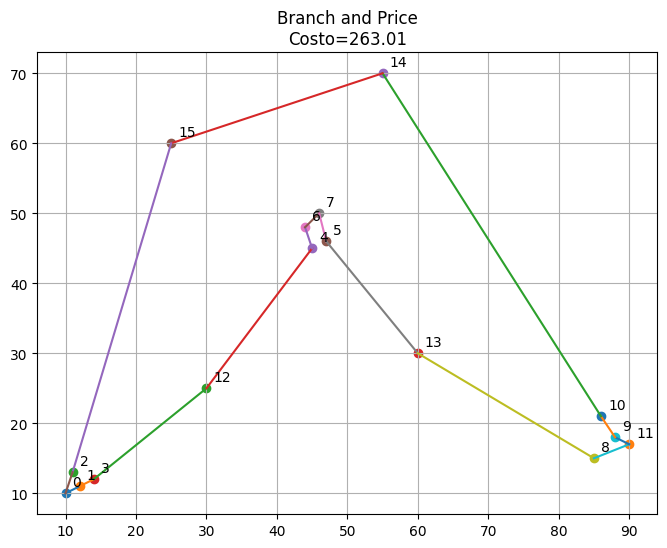

In [12]:
plt.figure(figsize=(8,6))

for i in range(len(ruta_price)-1):

    a = ruta_price[i]
    b = ruta_price[i+1]

    x1,y1 = ciudades[a]
    x2,y2 = ciudades[b]

    plt.plot(
        [x1,x2],
        [y1,y2]
    )

for indice,(x,y) in enumerate(ciudades):

    plt.scatter(x,y)

    plt.text(
        x+1,
        y+1,
        str(indice)
    )

plt.title(
    f"Branch and Price\nCosto={round(costo_price,2)}"
)

plt.grid(True)

plt.show()

#Branch and Price utiliza el mismo esquema de exploración y poda de Branch and Bound, pero incorpora un mecanismo de generación de columnas. En lugar de expandir todas las ciudades disponibles en cada etapa, selecciona únicamente las alternativas más prometedoras según la distancia al nodo actual. En esta implementación se generan como máximo tres candidatos por nivel del árbol. Esta estrategia reduce significativamente el número de nodos explorados y el tiempo de ejecución, ya que limita el tamaño del espacio de búsqueda a las opciones consideradas más atractivas. Aunque puede aumentar el riesgo de descartar rutas potencialmente buenas, permite obtener soluciones de forma mucho más eficiente.